### Scalable Speech Recognition Model Training

Title:
Memory-Efficient Transformer for Large-Scale Speech Recognition

Short Description:
This code implements a scalable end-to-end speech recognition system using chunked transformer blocks with gradient checkpointing. It processes LibriSpeech audio through convolutional feature extraction, memory-optimized transformer layers, and CTC loss training with mixed precision and gradient accumulation for efficient large-scale training.

Key Libraries Used:

    torch/torchaudio: Core deep learning and audio processing

    os/string: File handling and character mapping

    torch.utils.checkpoint: Memory optimization via gradient checkpointing

Code Logic and Flow

High-Level Overview:
The system processes LibriSpeech audio through mel-spectrogram conversion, uses convolutional downsampling, processes features through memory-efficient transformer blocks, and trains with CTC loss. It implements mixed precision training, gradient accumulation, and periodic checkpointing to enable large-scale model training with limited resources.

Visual FlowChart:

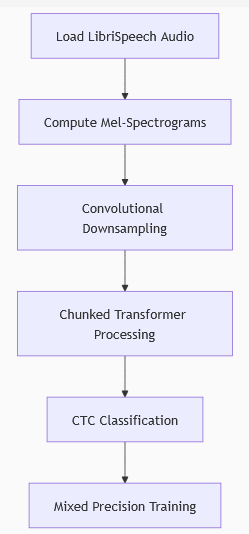

Step-by-Step Code Breakdown

Step 1: Dataset Handling

    Recursively scans directories for .trans.txt files

    Matches FLAC audio files to transcripts via utterance IDs

    Implements max_samples limit for resource-constrained experimentation

    Handles audio loading errors gracefully

Step 2: Audio Preprocessing

    Text Processing:

        Creates character mapping with CTC blank token

        Converts transcripts to numerical sequences

    Audio Processing:

        Converts stereo to mono

        Resamples to 16kHz standard rate

        Computes 80-band mel-spectrograms with 1024-point FFT

        Pads sequences to maximum length in batch

Step 3: Memory-Efficient Transformer

    Chunked Attention:

        Splits sequences into fixed-size chunks (default: 160 frames)

        Processes chunks sequentially to reduce memory footprint

    Gradient Checkpointing:

        Uses torch checkpoint for feedforward blocks

        Trades compute for memory savings

    Layer Components:

        Multi-head attention with residual connections

        GELU-activated feedforward network

        Layer normalization throughout

Step 4: Model Architecture

    Frontend:

        Two strided 1D convolutions (10x and 8x downsampling)

        Increases channels while reducing sequence length

    Backend:

        8-layer transformer encoder stack

        256-dimensional embeddings

        4 attention heads per layer

    Output:

        Linear projection to character probabilities

        Includes CTC blank token

Step 5: Optimized Training Loop

    Mixed Precision:

        Uses autocast for FP16 training

        Gradient scaling to prevent underflow

    Gradient Accumulation:

        Accumulates gradients over 4 batches

        Enables effective batch size of 8

    Efficiency Features:

        Fused Adam optimizer

        CTC loss with zero_infinity handling

        Periodic model checkpointing

Connecting to the Lecture**

    Memory Optimization: Chunked attention and gradient checkpointing enable larger models

    Mixed Precision: FP16 training doubles effective batch size

    Gradient Accumulation: Simulates larger batches with limited VRAM

    Scalable Architecture: Modular transformer design allows depth scaling

    Efficient Convolutions: Strided convolutions reduce sequence length

    CTC Loss: Alignment-free training for speech recognition

    Data Handling: Robust pipeline for real-world dataset variations

    Resource Management: Max_samples parameter enables prototyping

    Checkpointing: Preserves training progress for long-running jobs

    Modern Practices: Incorporates GELU activations and layer normalization

    Hardware Optimization: Automatic GPU/CPU fallback with fused operations

In [5]:
import os
import torch
import torchaudio
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.utils.checkpoint import checkpoint
import string

# 1. Custom Dataset for LibriSpeech with .trans.txt metadata
class MyLibriSpeechDataset(Dataset):
    def __init__(self, root, max_samples=10):
        self.samples = []
        self.transcripts = {}
        # Parse .trans or .trans.txt file in the root directory or subdirectories
        for dirpath, _, filenames in os.walk(root):
            for fname in filenames:
                if fname.endswith('.trans') or fname.endswith('.trans.txt'):
                    trans_path = os.path.join(dirpath, fname)
                    #print(f"Parsing transcript file: {trans_path}")
                    with open(trans_path, 'r', encoding='utf-8') as f:
                        for line in f:
                            parts = line.strip().split(' ', 1)
                            if len(parts) == 2:
                                utt_id, text = parts
                                utt_id = utt_id.strip().lower()
                                self.transcripts[utt_id] = text
        print("Transcript keys:", list(self.transcripts.keys())[:5])
        # Find .flac files and match with transcripts
        for dirpath, _, filenames in os.walk(root):
            for fname in filenames:
                if fname.endswith('.flac'):
                    utt_id = os.path.splitext(fname)[0].strip().lower()
                    audio_path = os.path.join(dirpath, fname)
                    if utt_id in self.transcripts and len(self.samples) < max_samples:
                        self.samples.append((audio_path, self.transcripts[utt_id]))
                    elif utt_id not in self.transcripts:
                        print(f"Transcript not found for: {audio_path}")
        print(f"Total samples found: {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        audio_path, transcript = self.samples[idx]
        try:
            waveform, sr = torchaudio.load(audio_path)
        except Exception as e:
            print(f"Error loading audio {audio_path}: {e}")
            raise
        return waveform, sr, transcript, audio_path

# 2. Preprocessing functions
alphabet = string.ascii_lowercase + " '"
char_to_idx = {c: i+1 for i, c in enumerate(alphabet)}  # 0 is reserved for CTC blank

def text_to_sequence(text):
    return torch.tensor([char_to_idx.get(c, 0) for c in text.lower() if c in char_to_idx], dtype=torch.long)

def compute_mels(wavs, sr=16000, n_mels=80):
    mels = []
    for wav in wavs:
        if wav.dim() > 1:
            wav = wav.mean(dim=0, keepdim=True)  # Convert to mono
        if sr != 16000:
            wav = torchaudio.transforms.Resample(sr, 16000)(wav)
        mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=16000, n_mels=n_mels, n_fft=1024, f_max=8000
        )
        mel = mel_transform(wav)  # (1, n_mels, time)
        mel = mel.squeeze(0).transpose(0, 1)  # (time, n_mels)
        mels.append(mel)
    max_len = max(mel.shape[0] for mel in mels)
    mels_padded = torch.stack([
        torch.nn.functional.pad(mel, (0, 0, 0, max_len - mel.shape[0])) for mel in mels
    ])
    return mels_padded.permute(0, 2, 1)  # (batch, n_mels, time)

# 3. Custom collate function
def collate_fn(batch):
    waveforms, srs, transcripts, audio_paths = zip(*batch)
    mels = compute_mels(waveforms, srs[0], n_mels=80)  # Assume same sample rate
    text_seqs = [text_to_sequence(t) for t in transcripts]
    text_lens = torch.tensor([len(seq) for seq in text_seqs])
    max_text_len = max(text_lens)
    text_padded = torch.zeros(len(text_seqs), max_text_len, dtype=torch.long)
    for i, seq in enumerate(text_seqs):
        text_padded[i, :len(seq)] = seq
    return mels, text_padded, text_lens

# 4. Memory-Efficient Transformer Block
class EfficientTransformerBlock(nn.Module):
    def __init__(self, d_model, nhead, chunk_size=160):
        super().__init__()
        self.chunk_size = chunk_size
        self.attn = nn.MultiheadAttention(d_model, nhead, batch_first=True)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, 4*d_model),
            nn.GELU(),
            nn.Linear(4*d_model, d_model)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def chunked_attention(self, x):
        chunks = x.split(self.chunk_size, 1)
        attn_out = []
        for chunk in chunks:
            attn, _ = self.attn(chunk, chunk, chunk)
            attn_out.append(attn)
        return torch.cat(attn_out, dim=1)

    def forward(self, x):
        x = self.norm1(x + self.chunked_attention(x))
        x = checkpoint(self._ffn_block, x)
        return x

    def _ffn_block(self, x):
        return self.norm2(x + self.ffn(x))

# 5. Scalable Speech Recognition Model
class ScalableSpeechLM(nn.Module):
    def __init__(self, layers=8, d_model=256, nhead=4, n_mels=80):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_mels, 64, 10, stride=2),
            nn.ReLU(),
            nn.Conv1d(64, d_model, 8, stride=2)
        )
        self.encoder = nn.ModuleList([
            EfficientTransformerBlock(d_model, nhead)
            for _ in range(layers)
        ])
        self.head = nn.Linear(d_model, len(char_to_idx) + 1)  # +1 for CTC blank

    def forward(self, x):
        x = self.conv(x)  # (batch, d_model, time)
        x = x.permute(0, 2, 1)  # (batch, time, d_model)
        for layer in self.encoder:
            x = layer(x)
        return self.head(x)

# 6. Initialize components
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ScalableSpeechLM(layers=8, d_model=256, n_mels=80).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters())/1e6:.1f}M")
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, fused=torch.cuda.is_available())
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
ctc_loss = nn.CTCLoss(blank=0, zero_infinity=True)
accum_steps = 4  # Virtual batch size = 8 (2*4)

# 7. Load subset of LibriSpeech
DATA_DIR = r"C:\Users\vinit_hqjv9wt\Desktop\FinFree Project\Courses\Deep learning for Speech language model\7 Challenges and Future Directions in SpeechLM Research\7.3 Scaling to Larger Models and Datasets\LibriSpeech"
dataset = MyLibriSpeechDataset(DATA_DIR, max_samples=10)
train_loader = DataLoader(dataset, batch_size=2, shuffle=True, collate_fn=collate_fn)

# 8. Training loop with model saving
os.makedirs(os.path.join(DATA_DIR, "trained_model"), exist_ok=True)  # Create trained_model directory
for epoch in range(5):
    print(f"Starting epoch {epoch}")
    model.train()
    for i, (mels, text_padded, text_lens) in enumerate(train_loader):
        try:
            with torch.amp.autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu'):
                mels = mels.to(device)  # (batch, n_mels, time)
                text_padded = text_padded.to(device)
                text_lens = text_lens.to(device)
                outputs = model(mels)  # (batch, time, vocab_size)
                log_probs = torch.log_softmax(outputs, dim=-1)  # (batch, time, vocab_size)
                input_lengths = torch.full((mels.size(0),), outputs.size(1), dtype=torch.long, device=device)
                loss = ctc_loss(
                    log_probs.permute(1, 0, 2),  # (time, batch, vocab_size)
                    text_padded,
                    input_lengths,
                    text_lens
                )
            scaler.scale(loss / accum_steps).backward()
            if (i + 1) % accum_steps == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
            print(f"    Epoch {epoch} | Batch {i} | Loss: {loss.item():.4f}")
        except Exception as e:
            print(f"    Error in epoch {epoch}, batch {i}: {e}")
            continue
    # Save model after each epoch
    model_path = os.path.join(r"C:\Users\vinit_hqjv9wt\Desktop\FinFree Project\Courses\Deep learning for Speech language model\7 Challenges and Future Directions in SpeechLM Research\7.3 Scaling to Larger Models and Datasets", "trained_model", f"speechlm_epoch_{epoch}.pt")
    torch.save(model.state_dict(), model_path)
    print(f"    Saved model to {model_path}")

Parameters: 6.5M


C:\Users\vinit_hqjv9wt\AppData\Local\Temp\ipykernel_21440\3041027197.py:147: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


Transcript keys: ['1272-128104-0000', '1272-128104-0001', '1272-128104-0002', '1272-128104-0003', '1272-128104-0004']
Total samples found: 10
Starting epoch 0
    Epoch 0 | Batch 0 | Loss: 0.0000
    Epoch 0 | Batch 1 | Loss: 0.0000
    Epoch 0 | Batch 2 | Loss: 2.2739
    Epoch 0 | Batch 3 | Loss: 3.1997
    Epoch 0 | Batch 4 | Loss: 1.6478
    Saved model to C:\Users\vinit_hqjv9wt\Desktop\FinFree Project\Courses\Deep learning for Speech language model\7 Challenges and Future Directions in SpeechLM Research\7.3 Scaling to Larger Models and Datasets\trained_model\speechlm_epoch_0.pt
Starting epoch 1
    Epoch 1 | Batch 0 | Loss: 1.9263
    Epoch 1 | Batch 1 | Loss: 1.5194
    Epoch 1 | Batch 2 | Loss: 1.8317
    Epoch 1 | Batch 3 | Loss: 1.8434
    Epoch 1 | Batch 4 | Loss: 0.0000
    Saved model to C:\Users\vinit_hqjv9wt\Desktop\FinFree Project\Courses\Deep learning for Speech language model\7 Challenges and Future Directions in SpeechLM Research\7.3 Scaling to Larger Models and Datas